In [1]:
import importlib, GallenModel, Landslidev2, metrics
from typing import Optional
importlib.reload(GallenModel)
importlib.reload(Landslidev2)
importlib.reload(metrics)
from tensorflow.keras.callbacks import CSVLogger
from sklearn.metrics import confusion_matrix
from tensorflow.keras import metrics
import tensorflow as tf
import json
import numpy as np
from tensorflow.keras.models import load_model
from imblearn.over_sampling import SMOTE
from imblearn import pipeline, under_sampling
import keras_tuner as kt
import sklearn
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split
import os
from matplotlib import pyplot as plt
import geopandas as gpd
import seaborn as sns
import shap
import pandas as pd
import matplotlib.colors as mcolors
import contextily as cx
from Landslidev2 import CotabatoModel, calculate_newmark
from metrics import plot_landslide_distribution
from sklearn.model_selection import KFold, StratifiedKFold
from metrics import plot_landslide_distribution, plot_confusion_matrix, plot_auc, plot_susceptibility_map, calculate_distribution
from GallenModel import build_model_pinn,LoggingRandomSearch, LandslideModel, NewmarkActivation, DisplacementLayer, LandslideActivationLayer, CohesionLayer, InternalFrictionLayer, NormalizationLayer, FosLayer # Custom layer used in the modelDisplacementLayer  

/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = gpd.read_file('~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_15_Training.gpkg')
df = df[df['Slope_mean'] >= 10]

# df['landslide'] = df['Landslide']

df.drop(columns=['landslide_probability', 'landslide_preds', 'confusion', 'sus_pinn_landslide', 'sus_pinn_ground truth', 'ds', 'cohesion', 'internal_friction'], inplace=True)

original_df_cols = df.columns
df.dropna(subset=list(original_df_cols), inplace=True) #cleans the dataframe by removing null rows for all columns

#encode string column to integer
df['Soil_Type'], _ = pd.factorize(df['Soil Type'])

original_df_cols = df.columns

In [3]:
cols_remove = ['DN', 'BD_mean', 'geometry', 'PGA2_max', 'Soil Type']
columns = [col for col in list(original_df_cols) if col not in cols_remove]
columns, df[columns].head()

(['Clay_mean',
  'Sand_mean',
  'Silt_mean',
  'NDVI_mean',
  'Est_mean',
  'Nrt_mean',
  'HorCurv_mean',
  'VertCurv_mean',
  'Slope_mean',
  'Elev_mean',
  'SoilThc_mean',
  'DistFlt_min',
  'LULC_majority',
  'TWI_mean',
  'PGA1_max',
  'Prc_mean',
  'Distrv_min',
  'distrd_min',
  'BUK_mean',
  'landslide',
  'Soil_Type'],
     Clay_mean   Sand_mean   Silt_mean  NDVI_mean  Est_mean  Nrt_mean  \
 0  360.346280  340.681485  298.954953   0.665530 -0.836117  0.452621   
 1  360.539905  341.044167  298.269993   0.515360 -0.642881  0.510736   
 2  358.393445  340.194179  301.392539   0.475615 -0.388284  0.865236   
 3  366.153165  332.831341  301.015494   0.787397  0.274677 -0.559830   
 4  360.236476  338.236476  301.527048   0.790155  0.545462 -0.813949   
 
    HorCurv_mean  VertCurv_mean  Slope_mean    Elev_mean  ...  DistFlt_min  \
 0      0.000846       0.000460   26.916097  1920.972112  ...  5593.218750   
 1      0.000765       0.000549   30.162405  1948.885717  ...  5535.918945 

In [4]:
cols_remove_for_sampling = ['landslide']
numeric_columns = [col for col in columns if col not in cols_remove_for_sampling]
print(numeric_columns)

['Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean', 'Est_mean', 'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean', 'Elev_mean', 'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean', 'PGA1_max', 'Prc_mean', 'Distrv_min', 'distrd_min', 'BUK_mean', 'Soil_Type']


In [5]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
train_x = {col:tf.convert_to_tensor(train_df[col].values.reshape(-1, 1), dtype=tf.float32) for col in numeric_columns}
train_y = train_df['landslide'].values
test_x = {col:tf.convert_to_tensor(test_df[col].values.reshape(-1, 1)) for col in numeric_columns}
test_y = test_df['landslide'].values
# train_ds = dataframe_to_dataset(train_df[columns])

In [6]:
model = load_model('trainedWeights/data-driven/model2.keras')

In [7]:
validation_df = gpd.read_file('~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_15_Validation.gpkg')
validation_df['Soil_Type'] = validation_df['Soil Type']

In [8]:
test_df = {col:tf.convert_to_tensor(validation_df[col].values.reshape(-1, 1)) for col in numeric_columns}


In [9]:
origin_preds = model.predict(test_df)

7797/7797 ━━━━━━━━━━━━━━━━━━━━ 4s 536us/step


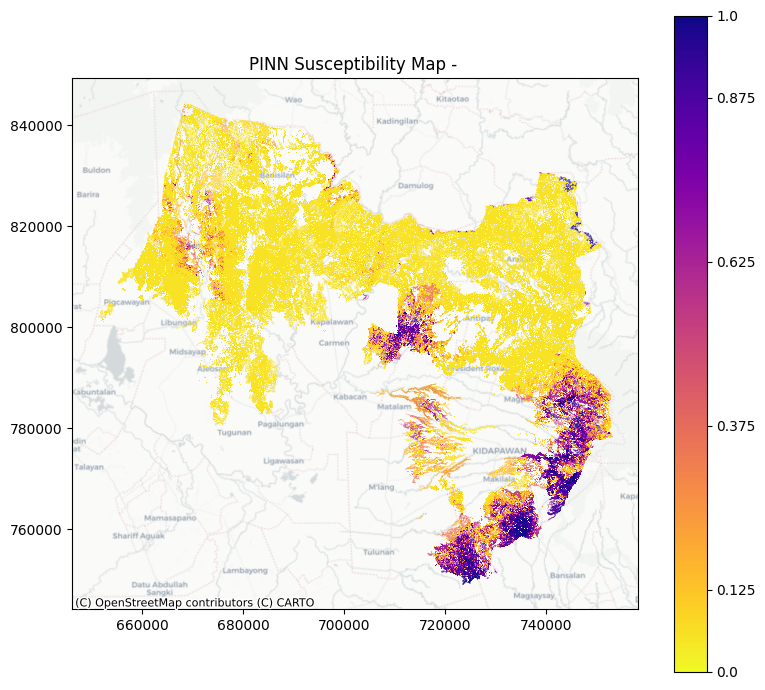

In [10]:
plot_susceptibility_map(validation_df, origin_preds, "")

In [11]:
distributions = calculate_distribution(vali dation_df)
print(distributions)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (755256884.py, line 1)